# Airbnb Price Prediction Pipeline

End-to-end run of the refactored pipeline in `src/`: clean the raw listings,
engineer features, train the fast model set (Linear Regression, Lasso,
from-scratch Gradient Descent, Random Forest, LightGBM, XGBoost), and compare
results. This notebook mirrors `main.py` but breaks it into cells with inline
plots so each step's output is visible.


## Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.config import CLEANED_TARGET_PATH, RANDOM_STATE, RAW_LISTINGS_PATH, TARGET_COLUMN, TEST_SIZE
from src.data.clean import clean_missing_target
from src.evaluate import print_metrics_log_target, regression_metrics_log_target
from src.features.build_features import build_feature_matrix
from src.models.linear_models import GradientDescentRegressor, train_lasso, train_linear_regression
from src.models.tree_models import train_lightgbm, train_random_forest, train_xgboost
from src.visualization.eda import plot_correlation_heatmap, plot_price_histogram, plot_price_percentiles
from src.visualization.model_viz import plot_actual_vs_predicted, plot_feature_importance


## Step 1: Clean missing target values

In [2]:
clean_missing_target(RAW_LISTINGS_PATH, CLEANED_TARGET_PATH, target_column=TARGET_COLUMN)
df = pd.read_csv(CLEANED_TARGET_PATH)
df.shape


Reading /Users/jnanadeep/Desktop/airbnb-price-prediction/data/raw/listings.csv...



--- Processing Summary ---
Initial row count:          40769
Rows with missing 'price': 953 (Removed)
Remaining row count:        39816
Cleaned data saved to:      /Users/jnanadeep/Desktop/airbnb-price-prediction/data/processed/airbnb_rio_cleaned_target.csv



(39816, 90)

## Step 2: Feature engineering\n\nNumerical imputation, column selection, price parsing, outlier removal, spatial + text features.

In [3]:
df = build_feature_matrix(df)
df.head()


Dropping columns with >90.0% missing values:
 - neighborhood_overview
 - host_since
 - host_response_time
 - host_response_rate
 - host_acceptance_rate
 - host_thumbnail_url
 - host_neighbourhood
 - host_total_listings_count
 - host_verifications
 - neighbourhood
 - neighbourhood_group_cleansed
 - calendar_updated
 - license
 - instant_bookable

Imputed 25 numerical columns using their median value.
--- Running Feature Selection ---
Original unique columns: 76
Filtered columns retained: 24
--- Running Dynamic Outlier Removal ---
Calculated 99.0th percentile threshold: $6,999.13
Removed 399 listing(s) outside the range [$10 - $6,999.13].
New maximum price in dataset: $6,990.00


,id,price,latitude,longitude,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,bathrooms_text,...,maximum_nights,availability_365,has_availability,number_of_reviews,review_scores_rating,reviews_per_month,description,dist_to_beach,amenity_count,desc_word_count
0,17878,565.00,-22.96599,-43.17940,Copacabana,Entire condo,Entire home/apt,5,1.0,1 bath,...,28.0,205,t,350,4.72,1.83,Please note that elevated rates apply for New ...,3.230662,26,96
1,25026,542.50,-22.97649,-43.19122,Copacabana,Entire rental unit,Entire home/apt,3,1.0,1 bath,...,21.0,196,t,325,4.76,1.69,"**Fully renovated in Dec 2022, new kitchen, n...",1.572651,38,88
2,35764,369.00,-22.98107,-43.19136,Copacabana,Entire loft,Entire home/apt,2,1.5,1.5 baths,...,15.0,96,t,548,4.90,2.90,Our newly renovated studio is located in the b...,1.374230,30,55
3,48305,4025.00,-22.98591,-43.20302,Ipanema,Entire rental unit,Entire home/apt,13,7.0,7 baths,...,89.0,259,t,185,4.77,1.01,Enter Bossa Nova's history by staying in the v...,0.298212,33,89
4,48901,1314.67,-22.96574,-43.17514,Copacabana,Entire rental unit,Entire home/apt,9,2.5,2.5 baths,...,1125.0,331,t,68,4.65,0.52,LARGE Beach side 4 bedrooms 2 Complete bathro...,3.602543,35,44


## Step 3: Exploratory visualizations

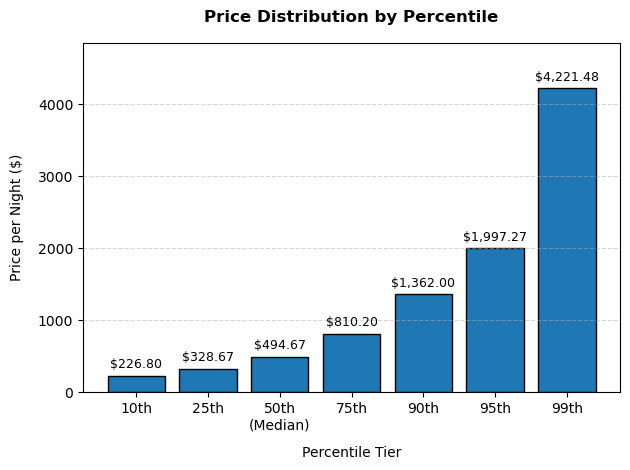

In [4]:
plot_price_percentiles(df)

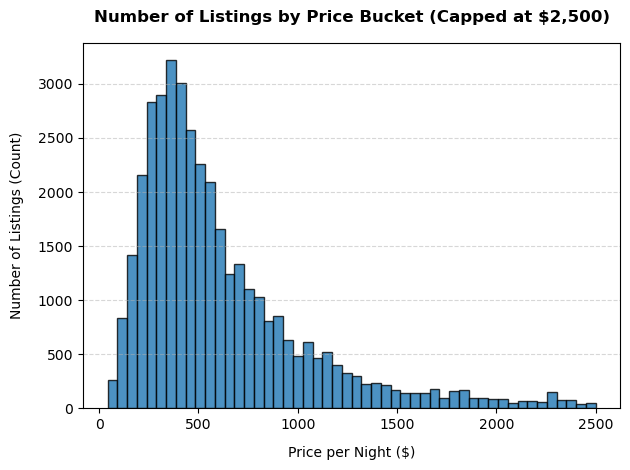

In [5]:
plot_price_histogram(df)

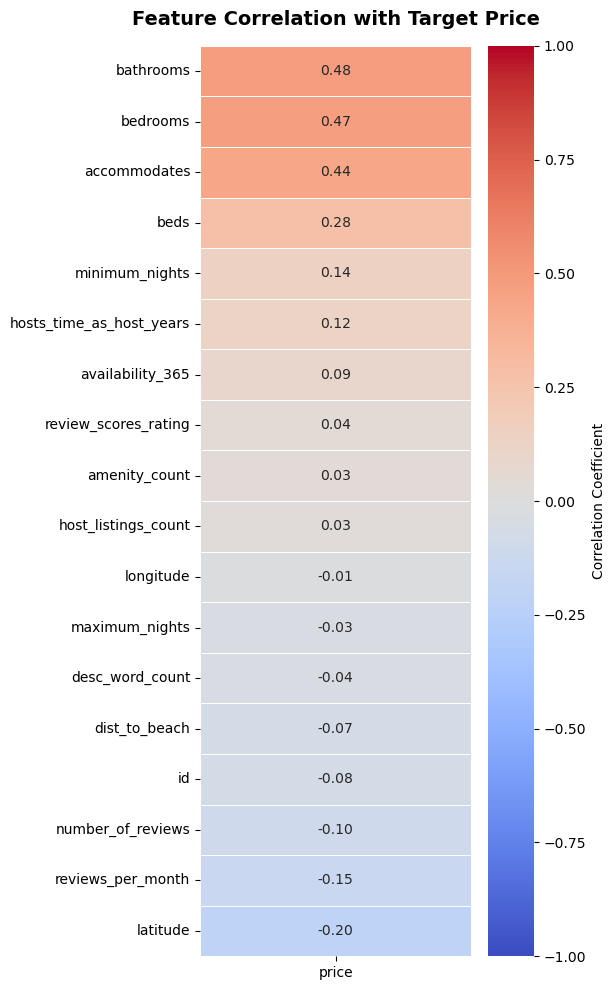

In [6]:
plot_correlation_heatmap(df)

## Step 4: Train/test split + feature scaling\n\n`id` is dropped -- it's a listing identifier (some IDs are 19-digit numbers), not a predictive feature, and its scale destabilizes the linear models.

In [7]:
X = df.drop(columns=[TARGET_COLUMN, "id"], errors="ignore").select_dtypes(include=[np.number])
y_log = np.log1p(df[TARGET_COLUMN])

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Feature matrix shape: {X_train.shape}")


Feature matrix shape: (31533, 17)


## Step 5: Train models\n\nAll models are trained on `log1p(price)`. MAE/RMSE are reported back in real dollars, but R^2 is computed in log-space -- the scale the models were actually optimized on -- matching the original notebook's convention.

### Linear Regression

In [8]:
lr_model = train_linear_regression(X_train_scaled, y_train_log)
lr_preds_log = lr_model.predict(X_test_scaled)
print_metrics_log_target("Linear Regression", y_test_log, lr_preds_log)


Linear Regression              | R^2 Score: 43.89% | MAE: $304.34 | RMSE: $601.56


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


{'mae': 304.34374010628375,
 'rmse': np.float64(601.56097738569),
 'r2': 0.43891109506982606}

### Lasso

In [9]:
lasso_model = train_lasso(X_train_scaled, y_train_log)
lasso_preds_log = lasso_model.predict(X_test_scaled)
print_metrics_log_target("Lasso", y_test_log, lasso_preds_log)


Lasso                          | R^2 Score: -0.07% | MAE: $403.43 | RMSE: $766.11


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


{'mae': 403.43367331039593,
 'rmse': np.float64(766.1131518950003),
 'r2': -0.0006529699443751369}

### Gradient Descent (from scratch)

In [10]:
gd_model = GradientDescentRegressor(learning_rate=0.05, epochs=600)
gd_model.fit(X_train_scaled, y_train_log)
gd_preds_log = gd_model.predict(X_test_scaled)
print_metrics_log_target("Gradient Descent", y_test_log, gd_preds_log)


Gradient Descent               | R^2 Score: 43.89% | MAE: $304.46 | RMSE: $601.83


{'mae': 304.46218247218,
 'rmse': np.float64(601.8327189867326),
 'r2': 0.43887287983145074}

### Random Forest

In [11]:
rf_model = train_random_forest(X_train, y_train_log)
rf_preds_log = rf_model.predict(X_test)
print_metrics_log_target("Random Forest", y_test_log, rf_preds_log)


Random Forest                  | R^2 Score: 59.74% | MAE: $261.61 | RMSE: $527.83


{'mae': 261.6086407228672,
 'rmse': np.float64(527.8281306073268),
 'r2': 0.5974019333992417}

### LightGBM

In [12]:
lgb_model = train_lightgbm(X_train, y_train_log)
lgb_preds_log = lgb_model.predict(X_test)
print_metrics_log_target("LightGBM", y_test_log, lgb_preds_log)


LightGBM                       | R^2 Score: 61.77% | MAE: $257.22 | RMSE: $515.29


{'mae': 257.21522713164273,
 'rmse': np.float64(515.2887411099425),
 'r2': 0.6177361289845608}

### XGBoost

In [13]:
xgb_model = train_xgboost(X_train, y_train_log)
xgb_preds_log = xgb_model.predict(X_test)
print_metrics_log_target("XGBoost", y_test_log, xgb_preds_log)


XGBoost                        | R^2 Score: 61.94% | MAE: $255.30 | RMSE: $514.38


{'mae': 255.29808488784857,
 'rmse': np.float64(514.3767488553694),
 'r2': 0.6193945389329365}

## Step 6: Model comparison

In [14]:
predictions_log = {
    "Linear Regression": lr_preds_log,
    "Lasso": lasso_preds_log,
    "Gradient Descent": gd_preds_log,
    "Random Forest": rf_preds_log,
    "LightGBM": lgb_preds_log,
    "XGBoost": xgb_preds_log,
}

comparison = pd.DataFrame({
    name: regression_metrics_log_target(y_test_log, preds_log)
    for name, preds_log in predictions_log.items()
}).T.sort_values(by="r2", ascending=False)

comparison


,mae,rmse,r2
XGBoost,255.298085,514.376749,0.619395
LightGBM,257.215227,515.288741,0.617736
Random Forest,261.608641,527.828131,0.597402
Linear Regression,304.343740,601.560977,0.438911
Gradient Descent,304.462182,601.832719,0.438873
Lasso,403.433673,766.113152,-0.000653


## Step 7: Actual vs. predicted price trends

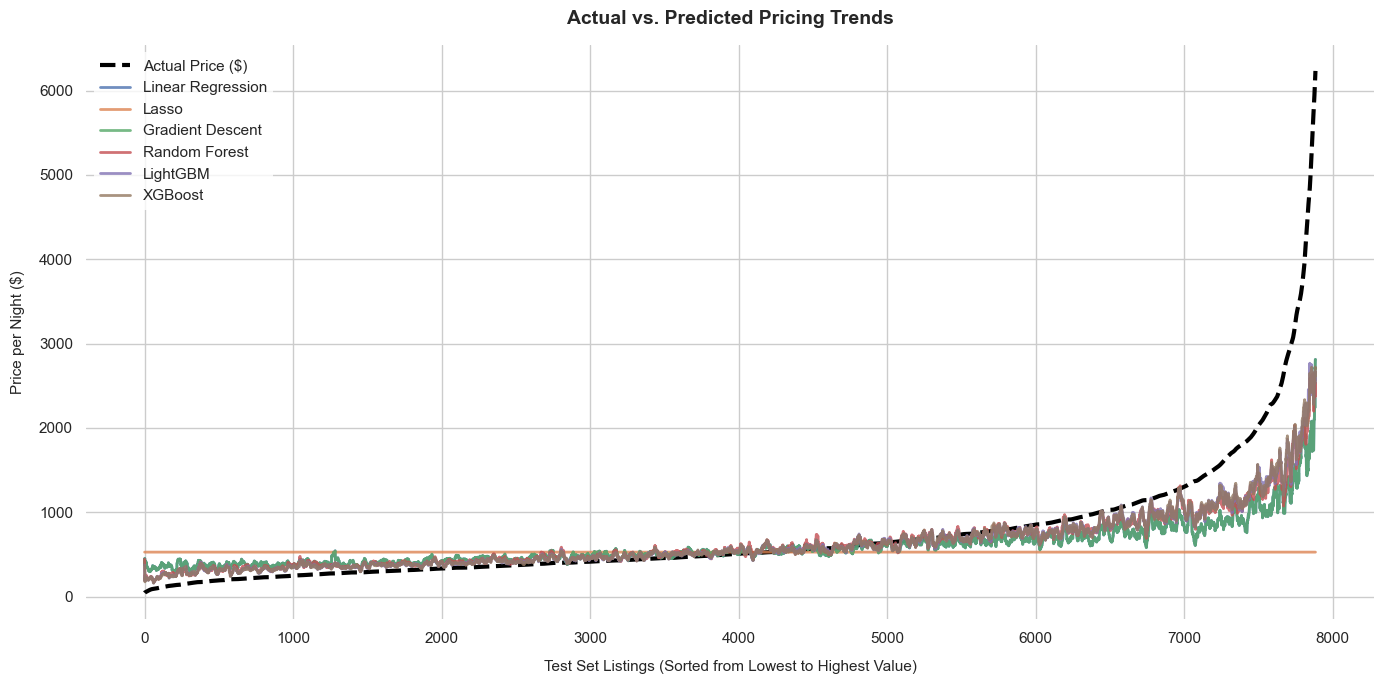

In [15]:
predictions_actual = {name: np.expm1(preds) for name, preds in predictions_log.items()}
plot_actual_vs_predicted(np.expm1(y_test_log).values, predictions_actual)


## Step 8: Feature importance (XGBoost)

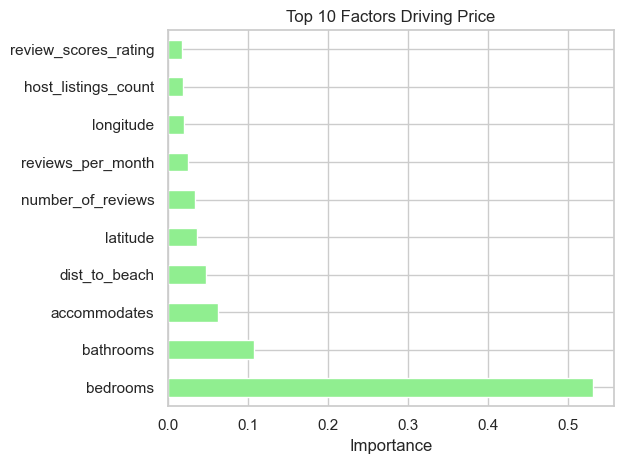

In [16]:
plot_feature_importance(xgb_model, X_train.columns)